# P10: Validation

This protocol is the validation gate: a short, ordered battery of internal sanity checks that asks whether a CPP **signature** (from *P1: CPP signature*) and any classifier you build on it can be trusted before you attach a biological claim to a number. A signature can look convincing on a few dozen sequences and still be an artefact of overfitting, leakage, or plain luck, so we validate a **determinant-discovery** result by asking: would it survive resampling and a shuffled-label control?

A result you cannot reproduce, and cannot beat a shuffled-label control with, is not a result. Validation is not about squeezing out a higher score; it is about proving the score tracks the **labels** (the real **test group** vs **reference group** contrast) and not noise. The single most informative line in this entire protocol is *real vs shuffled*: if scrambling the labels does not destroy performance, the pipeline is leaking and no other number can be trusted.

The headline output is a single figure (the **per-protein rank plot** below, where substrate TMDs rank above non-substrates), backed by the **real-vs-shuffled** control further down that proves the ranking tracks the labels and not noise.

**When to use it.** Use this protocol **after** you have a signature and/or a fitted classifier, and **before** you report a number or draw a biological conclusion. It answers the reviewer's first question: *"Is this real, or did the model just memorise 40 sequences?"*

We stay on the gamma-secretase task (`DOM_GSEC`), a **domain-level** problem: the **unit of comparison** is the transmembrane-domain (TMD) **part** set, the **test group** is substrate TMDs (`label=1`) and the **reference group** is non-substrate TMDs (`label=0`). A trustworthy result means the physicochemical separation captured by the signature is stable under resampling and survives the controls below, not that we fit noise.

The checklist mirrors six questions:

| Check | Question it answers |
| --- | --- |
| Repeated stratified CV | Does performance hold across many train/test splits, not one lucky one? |
| Bootstrap CI of the mean | How wide is the uncertainty band around the score? |
| Shuffled-label control | Does the score **collapse** when the labels carry no information? |
| Feature stability | Do the top features keep their effect sizes under resampling? |
| Biological sense | Do the strongest features match known biology? |
| Generalization headroom (learning curve) | Is the task sampling-limited: would more TMDs still raise the score, or has it plateaued? |

**When *not* to use it.** All six checks are **internal**: they resample the same 40 TMDs and cross-validate in-sample. They tell you whether a result is stable and not an artefact; they do **not** measure external generalization. If your question is "will this signature transfer to a *different* dataset?", this protocol is not enough: you need a true external hold-out (a separate, unseen set of proteins). And do not reach for this protocol before you have a signature: build one first with *P1: CPP signature*.

**Input.** The same input as *P1: CPP signature*: a `df_seq` with one row per protein, a binary `label` column (**test group** = 1, **reference group** = 0) and the domain coordinates (`tmd_start` / `tmd_stop`). We rebuild the **signature** (`df_feat`) and the **feature matrix** `X` exactly as in P1, then validate them.

If you arrived here straight from P1 you already have `df_feat` and `X`; the cell below reproduces them so this protocol stands on its own. We keep the fixture small (`n=20`, giving 40 balanced TMDs) and the cross-validation light, so the whole checklist runs in seconds.

In [1]:
import warnings
import numpy as np
import aaanalysis as aa

aa.options["verbose"] = False
aa.options["random_state"] = 42

# Rebuild the Protocol 1 signature on a small balanced fixture
df_seq = aa.load_dataset(name="DOM_GSEC", n=20)      # 20 per class -> 40 rows
labels = np.array(df_seq["label"].to_list())

sf = aa.SequenceFeature()
df_parts = sf.get_df_parts(df_seq=df_seq)
cpp = aa.CPP(df_parts=df_parts)
df_feat = cpp.run(labels=labels, n_filter=25, n_jobs=1)

# Feature matrix: rows = TMDs, columns = the 25 selected features
X = sf.feature_matrix(features=df_feat["feature"], df_parts=df_parts)
X.shape, df_feat.shape

((40, 25), (25, 13))

**Run.** Each check is one small cell. We use a `RandomForestClassifier` as a neutral downstream model and the **Matthews correlation coefficient (MCC)** as the headline metric: MCC is balanced, ranges from -1 to 1, and reads ~0 for a model that has learned nothing, which is exactly what makes the shuffled-label control easy to read. (AAanalysis ships its own tree classifier, `aa.TreeModel`, whose `.eval` scores feature-set quality with k-fold CV (see the comparison-harness tutorial, tutorial6, for the function details); for the native-evaluator path see *P7: Build a classifier*. Here we drive a raw RandomForest so every control stays explicit and framework-agnostic.)

**Check 1: repeated stratified cross-validation.** `RepeatedStratifiedKFold` keeps the 50/50 class balance in every fold and repeats the whole split several times, so the score is an average over many train/test partitions rather than one lucky one.

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.metrics import matthews_corrcoef, make_scorer

clf = RandomForestClassifier(n_estimators=100, random_state=42)
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)  # 15 fits
mcc = make_scorer(matthews_corrcoef)

scores = cross_val_score(clf, X, labels, cv=cv, scoring=mcc)
float(scores.mean()), float(scores.std())

(0.8070022769184196, 0.17911074334561763)

**Headline figure: per-protein rank plot.** The deployment-view sanity check. We turn the cross-validation into one **out-of-fold** substrate probability per TMD (every protein scored only by folds that never saw it), then rank proteins high-to-low with `aa.plot_rank` and color each by its true group. A trustworthy signature ranks **substrate** TMDs (test group) above **non-substrate** TMDs (reference group); the dashed line is the deployment threshold a caller would apply. This is the single most useful one-glance check, and the controls below (starting with *real vs shuffled*) are what make the separation believable.

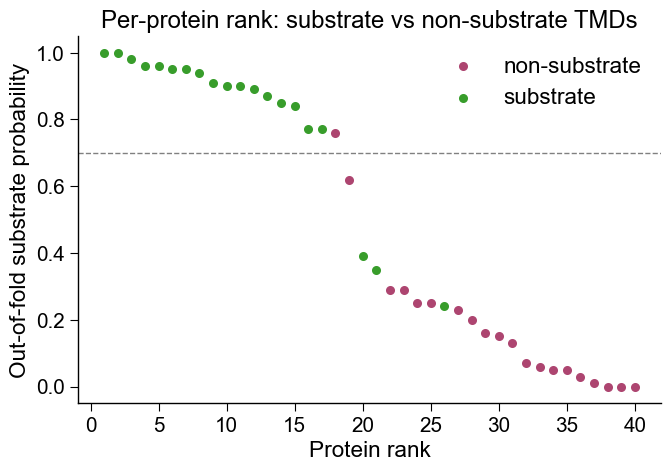

In [3]:
# Headline figure: per-protein rank plot (the deployment-view sanity check)
# One out-of-fold substrate probability per TMD: each protein is scored only by
# the folds that never trained on it, so the ranking is honest (no leakage).
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_predict

cv_pred = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
proba = cross_val_predict(clf, X, labels, cv=cv_pred, method="predict_proba")[:, 1]
df_rank = pd.DataFrame({
    "score": proba,
    "group": np.where(labels == 1, "substrate", "non-substrate"),
})

aa.plot_settings(font_scale=0.9, weight_bold=False)
fig, ax = aa.plot_rank(df_rank=df_rank, threshold=0.7,
                       ylabel="Out-of-fold substrate probability")
ax.set_title("Per-protein rank: substrate vs non-substrate TMDs",
             size=aa.plot_gcfs() + 1)
plt.tight_layout()
plt.show()

**Check 2: bootstrap confidence interval.** `comp_bootstrap_ci` resamples the 15 fold scores with replacement (seed-locked) to put a 95% interval around the mean MCC, so we report a band rather than a bare point estimate.

In [4]:
# Check 2 - Bootstrap confidence interval of the mean MCC
# comp_bootstrap_ci resamples the 15 fold scores with replacement (seed-locked).
ci = aa.comp_bootstrap_ci(values=scores, n_rounds=1000, ci=0.95, seed=42)
ci

{'mean': 0.8070022769184196,
 'ci_low': 0.7139891620269944,
 'ci_high': 0.8967358359109805}

**Check 3: shuffled-label (negative) control.** The single most informative check, and the one this whole protocol rests on: permute the labels so they carry no information and confirm the score collapses toward MCC ~ 0. We average over several reshuffles so the null is a mean over many draws, not one noisy point. The figure just below makes the gap visible. Here we average over only **10** permutations to stay inside the per-cell time budget; a production run should use many more (e.g. >=100) for a smoother null.

In [5]:
# Check 3 - Shuffled-label (negative) control
# Permute the labels many times: any structure left is pure chance. A
# trustworthy signature collapses toward MCC ~ 0 here. We average over
# several reshuffles so the null is a mean over many splits, not a single
# noisy point estimate (the same 'many resamples' logic as Check 1).
rng = np.random.default_rng(42)
shuffled_means = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")          # degenerate shuffled folds -> expected MCC warnings
    for _ in range(10):
        labels_shuffled = rng.permutation(labels)
        s = cross_val_score(clf, X, labels_shuffled, cv=cv, scoring=mcc)
        shuffled_means.append(s.mean())
{"real_MCC": round(float(scores.mean()), 3),
 "shuffled_MCC_mean": round(float(np.mean(shuffled_means)), 3),
 "shuffled_MCC_max": round(float(np.max(shuffled_means)), 3)}

{'real_MCC': 0.807, 'shuffled_MCC_mean': 0.051, 'shuffled_MCC_max': 0.252}

A few things happened here. The figure contrasts the 15 real cross-validation fold scores (right) against the shuffled-label null (left). This is the protocol's key control picture, the one that backs the rank plot above: notice how the two clouds barely overlap, the real folds sit high while the shuffled control hugs MCC ~ 0. That obvious gap *is* the evidence that the signature tracks the labels, not chance.

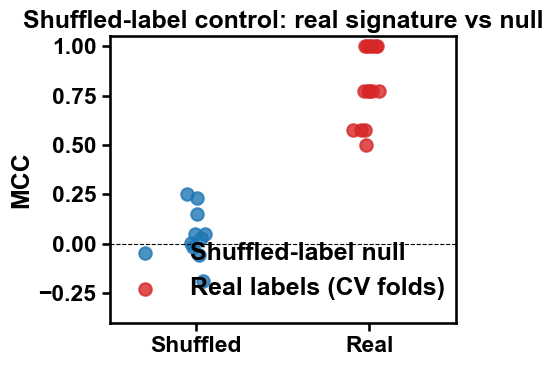

In [6]:
# Headline figure: shuffled-label control (made visible)
import matplotlib.pyplot as plt
aa.plot_settings()
c_null, c_real = aa.plot_get_clist(n_colors=2)  # consistent with the CPP figures

fig, ax = plt.subplots(figsize=(5, 4))
jit = np.random.default_rng(0)
x_shuf = jit.normal(0.0, 0.04, size=len(shuffled_means))
x_real = 1 + jit.normal(0.0, 0.04, size=len(scores))
ax.scatter(x_shuf, shuffled_means, color=c_null, alpha=0.8, label="Shuffled-label null")
ax.scatter(x_real, scores, color=c_real, alpha=0.8, label="Real labels (CV folds)")
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Shuffled", "Real"])
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.4, 1.05)
ax.set_ylabel("MCC")
ax.set_title("Shuffled-label control: real signature vs null")
ax.legend(frameon=False, loc="lower center")
plt.tight_layout()
plt.show()

**Check 4: feature stability under resampling.** Recompute each feature's adjusted-AUC effect size on bootstrap resamples and correlate it with the full-data effect sizes. A high correlation means the **signature** reflects real effect sizes, not resampling noise. We use just **5** bootstrap resamples here for speed; on a real study raise this to >=100 so the stability estimate is not itself noisy.

In [7]:
# Check 4 - Feature stability under resampling
# Recompute the adjusted AUC (effect size, [-0.5, 0.5]) for every feature on
# bootstrap resamples and correlate it with the full-data effect sizes.
# High correlation = the signature's effect sizes are not resampling artefacts.
# Re-seed here so this cell is reproducible on its own (not dependent on the
# RNG state left by Check 3).
rng = np.random.default_rng(42)
auc_full = aa.comp_auc_adjusted(X=X, labels=labels)
corrs = []
for _ in range(5):
    idx = rng.choice(len(labels), size=len(labels), replace=True)
    while len(np.unique(labels[idx])) < 2:          # keep both classes present
        idx = rng.choice(len(labels), size=len(labels), replace=True)
    auc_b = aa.comp_auc_adjusted(X=X[idx], labels=labels[idx])
    corrs.append(np.corrcoef(auc_full, auc_b)[0, 1])
round(float(np.mean(corrs)), 3)

0.992

**Check 5 and 6: biological sense and generalization headroom (learning curve).** Read the strongest features against known substrate biology, then use a learning curve to ask whether the task is **sampling-limited**: would more TMDs still raise the score, or has the signal plateaued?

For `DOM_GSEC`, the expected substrate physicochemistry around the cleavage site is **helix-destabilizing / helix-breaking propensity, β-turn and flexibility signals** (a locally less rigid, more bendable helix lets gamma-secretase unwind and cleave the TMD). So α-helix, β-turn and folding free-energy **subcategories** topping the list is the biologically sensible outcome; charge or bulky-hydrophobicity terms dominating instead would be a red flag.

Note: this is **internal** in-sample cross-validation over the same 40 TMDs, it measures sampling headroom, not external generalization. A true external-generalization estimate needs a separate hold-out dataset.

In [8]:
# Check 5/6 - Biological sense + generalization headroom (learning curve)
# Top features by effect size: do the strongest physicochemical properties
# match known substrate biology? For DOM_GSEC we expect helix-destabilizing /
# β-turn / flexibility signals near the cleavage site (read the subcategory).
top = df_feat.reindex(df_feat["abs_auc"].sort_values(ascending=False).index)
aa.display_df(df=top[["feature", "category", "subcategory", "mean_dif", "abs_auc"]], n_rows=5)

# Learning curve (INTERNAL in-sample CV, no external hold-out): does the score
# still climb with more TMDs (the task is sampling-limited, more data would
# help) or has it plateaued (the signal is captured)? We start at 0.6 of the
# training fold so the smallest size keeps both classes (a smaller size makes
# MCC undefined, the tiny-fold trap flagged under Common mistakes).
from sklearn.model_selection import learning_curve
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    sizes, train_sc, test_sc = learning_curve(
        clf, X, labels, cv=cv, scoring=mcc,
        train_sizes=np.linspace(0.6, 1.0, 4))
{"train_sizes": sizes.tolist(),
 "test_MCC_by_size": np.round(test_sc.mean(axis=1), 3).tolist()}

,feature,category,subcategory,mean_dif,abs_auc
1,"TMD-Pattern(C,4,8)-BEGF750101",Conformation,α-helix,0.299000,0.444000
2,"TMD_C_JMD_C-Pat...4,8)-BEGF750101",Conformation,α-helix,0.299000,0.444000
3,"TMD_C_JMD_C-Pat...,12)-CRAJ730103",Conformation,β-turn,-0.251000,0.431000
4,"TMD_C_JMD_C-Pat...,12)-MUNV940102",Energy,Free energy (folding),-0.148000,0.422000
5,"TMD_C_JMD_C-Per...4,2)-BEGF750103",Conformation,β-turn,-0.139000,0.409000


{'train_sizes': [19, 23, 27, 32],
 'test_MCC_by_size': [0.696, 0.778, 0.792, 0.807]}

**Output.** The headline output is the **per-protein rank plot** above: substrate TMDs ranking above non-substrates, with the deployment threshold drawn in. Its credibility rests on the **real-vs-shuffled figure**, where the wide vertical gap between the real cross-validation fold scores and the shuffled-label null *is* the evidence that the ranking tracks the labels. Everything else is a small panel of scalars you can paste straight into a methods section:

- `df_rank`: one out-of-fold substrate probability per TMD plus its true group, the table behind the rank plot.
- `scores.mean()` / `scores.std()`: mean repeated-CV MCC and its spread across 15 fits.
- `ci`: dictionary `{'mean', 'ci_low', 'ci_high'}`, the 95% bootstrap interval of the mean MCC. Caveat: the 15 `RepeatedStratifiedKFold` folds share most of their training data, so they are not independent samples; bootstrapping them understates uncertainty, making this band a *lower bound* on the true interval. The only honest test of generalization is an external hold-out.
- `real_MCC` vs `shuffled_MCC_mean` / `shuffled_MCC_max`: the headline score against its negative control, averaged (and worst-cased) over 10 independent label permutations.
- the stability correlation: mean Pearson correlation of per-feature effect sizes across bootstrap resamples (1.0 = an identical effect-size profile every time).
- `top`: the five strongest features for the biological-sense eyeball check.
- `test_MCC_by_size`: MCC as a function of training-set size (the learning curve).

**How to interpret.** Each output maps to a trustworthy reading and a warning sign:

| Output | Trustworthy result | Warning sign |
| --- | --- | --- |
| repeated-CV `MCC` | high and stable (low `std`) | high mean but large `std` -> split-dependent |
| bootstrap `ci` | narrow, well above 0 | wide band crossing ~0 -> under-powered |
| `shuffled_MCC_mean` | **collapses** far below the real MCC (toward 0) | stays high -> leakage / the metric is not measuring signal |
| stability correlation | close to 1.0 | low / variable -> effect sizes are resampling noise |
| `top` features | **subcategories** match expected GSEC-substrate biology (helix-destabilizing / β-turn / flexibility near the cleavage site) | top features biologically implausible (e.g. charge / bulk dominating) -> suspect overfitting |
| learning curve (internal CV) | rising then plateauing | flat and low -> features carry little signal; still steeply rising -> task is sampling-limited, more data needed |

On this fixture the real MCC sits high while the shuffled control drops sharply toward 0: the separation tracks the labels, not an artefact.

**Key takeaways**

- *Real vs shuffled is the gate.* If scrambling the labels does not destroy performance, the pipeline is leaking and every other number is meaningless. Always run the negative control first.
- *Report a band, never a point.* With only 40 TMDs every number is under-powered; quote the bootstrap interval, not a bare MCC.
- *Internal is not external.* All six checks resample the same TMDs. Surviving them earns trust in stability, not a promise of transfer: confirm external generalization on a separate dataset.

**Common mistakes.** The traps below sink most validation attempts:

- **No shuffled-label control.** A high CV score alone proves nothing; only the *gap* between real and shuffled performance does. Always run the negative control.
- **Plain K-fold instead of stratified.** With 40 rows an unstratified split can leave a fold with one class, making MCC undefined or wildly unstable. Use `RepeatedStratifiedKFold`.
- **Reporting a point estimate.** A single MCC hides the uncertainty. Report the bootstrap CI (`comp_bootstrap_ci`) of the mean.
- **Re-selecting features inside the loop is skipped here for speed.** On a real study, run CPP feature selection *inside* each CV fold to avoid selection leakage; reusing one global `df_feat` mildly optimistically biases the score.
- **Over-reading a single feature.** Interpret the *signature* as blocks of related features; check effect-size stability before any biological claim.
- **Using `len(df_seq)` for class sizes.** `load_dataset(name=..., n=N)` returns `2N` rows (N per class); use the `label` column.

**Next step.** You have run the internal validation gate: repeated stratified CV with a bootstrap CI, a shuffled-label control, feature-stability under resampling, a biological-sense read and a learning curve. If the result survived all of them it is ready to report, with the standing caveat that external generalization still needs a separate hold-out dataset.

- **Loop back to *P1: CPP signature*** and apply the whole workflow to a new dataset: the surest external-generalization test is to rebuild the signature on a fresh, unseen set of proteins and re-run this validation gate there.
- **Revisit *P1: CPP signature*** sooner if a control failed: rebuild or tighten the signature before you report a number.
- **Quantify uncertainty per protein** for **residue-level** / windowed site-prediction tasks (not this domain task), pairing `comp_per_protein_ap` with `comp_bootstrap_ci` for protein-level confidence intervals.